In [112]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
train_df = pd.read_csv('newdata/cs-training.csv')
test_df = pd.read_csv('newdata/cs-test.csv')

In [114]:
train_df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [115]:
train_df.drop('Unnamed: 0',axis=1,inplace=True)

In [116]:
test_df.drop('Unnamed: 0',axis=1,inplace=True)

In [117]:
train_df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [118]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

#### Медиана примерно одинаковая - прилежные заёмщики и неприлежные зарабатывают в большинстве случаев примерно одинаково

In [119]:
train_df.groupby('SeriousDlqin2yrs')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,,,,,,,,
0,111912.0,6747.837774,14813.502224,0.0,3461.0,5466.0,8333.0,3008750.0
1,8357.0,5630.826493,6171.719674,0.0,2963.0,4500.0,6800.0,250000.0


#### Есть люди с большим доходом, которые не возвращали кредит

In [120]:
filt = (train_df['SeriousDlqin2yrs']==1) & (train_df['MonthlyIncome']> train_df['MonthlyIncome'].quantile(0.95))                                 

In [121]:
train_df[train_df['MonthlyIncome']> train_df['MonthlyIncome'].quantile(0.95)].groupby('SeriousDlqin2yrs')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,,,,,,,,
0,5734.0,25719.505581,60965.463591,14588.0,16000.0,18000.0,23000.00,3008750.0
1,280.0,24951.592857,22735.404515,14600.0,16000.0,18444.0,24353.25,250000.0


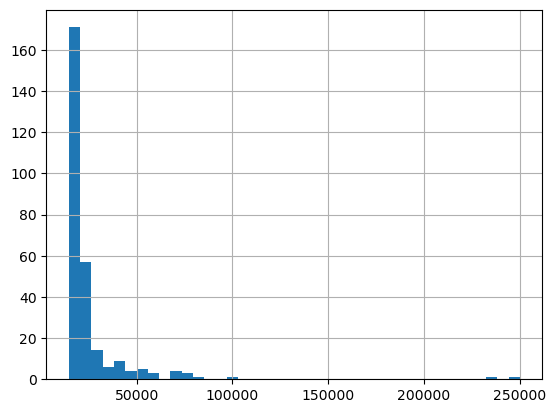

In [122]:
train_df[filt]['MonthlyIncome'].hist(bins=40)
plt.show()

In [123]:
train_df[filt].sort_values('MonthlyIncome').tail(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
35354,1,0.168316,54,0,0.008516,70575.0,4,1,0,1,1.0
118010,1,1.000000,56,0,0.023253,71000.0,2,1,1,0,3.0
109557,1,0.357761,61,3,0.015805,72000.0,8,1,1,0,1.0
18922,1,1.000000,56,1,0.078012,78000.0,6,1,1,0,3.0
114724,1,0.854706,40,0,0.021025,78000.0,6,0,1,0,2.0
9477,1,0.136994,35,0,0.021669,78500.0,4,0,1,0,2.0
6658,1,0.804867,31,2,0.005642,81000.0,5,0,0,0,2.0
142222,1,0.333434,58,0,0.093646,101167.0,19,0,7,0,0.0
67678,1,0.000000,53,4,0.050533,234600.0,17,1,6,1,0.0
34770,1,0.375783,62,0,0.022712,250000.0,15,0,2,0,0.0


In [124]:
train_df = train_df[train_df['MonthlyIncome'] < 100000]

#### 1634 Человек брали кредит, имея 0 доход

In [125]:
train_df[train_df['MonthlyIncome'] == 0].shape

(1634, 11)

In [126]:
train_df[train_df['MonthlyIncome'] == 0].describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,1634.000000,1634.000000,1634.000000,1634.000000,1634.000000,1634.0,1634.000000,1634.000000,1634.000000,1634.000000,1634.000000
mean,0.040392,4.295944,48.337209,0.596695,1573.567319,0.0,7.061812,0.485924,0.716646,0.463892,0.730722
std,0.196936,146.618763,16.686167,6.416796,2818.015889,0.0,4.849654,6.415219,0.903761,6.408830,1.186657
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.020265,35.000000,0.000000,96.000000,0.0,3.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.109118,47.000000,0.000000,930.000000,0.0,6.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.482331,61.000000,0.000000,2185.250000,0.0,10.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,5893.000000,97.000000,98.000000,60212.000000,0.0,31.000000,98.000000,9.000000,98.000000,10.000000


In [127]:
#train_df = train_df[train_df['MonthlyIncome'] != 0]

In [128]:
train_df.loc[train_df[train_df['MonthlyIncome'] == 0].index,:]['MonthlyIncome'] = train_df['MonthlyIncome'].median()

In [129]:
train_df['MonthlyIncome'].isna().sum()

0

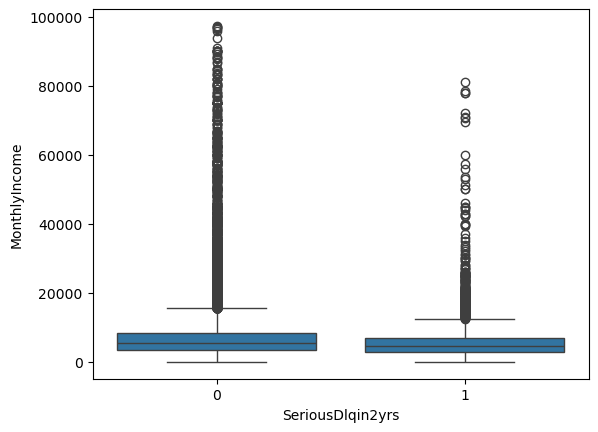

In [130]:
sns.boxplot(x='SeriousDlqin2yrs',y='MonthlyIncome',data = train_df.dropna())
plt.show()

In [131]:
Income_no_outliers = train_df[train_df['MonthlyIncome']  <train_df['MonthlyIncome'].quantile(0.85)]

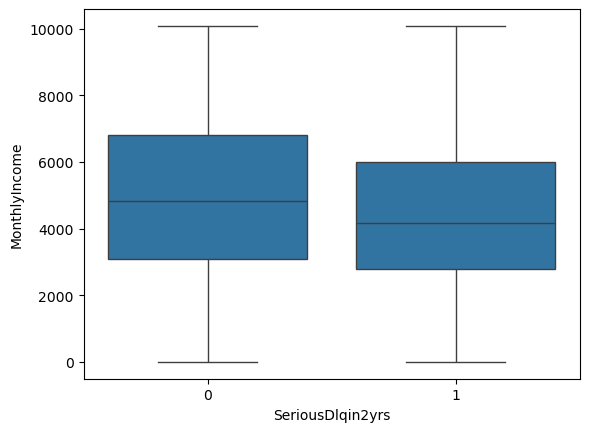

In [132]:
sns.boxplot(x='SeriousDlqin2yrs',y='MonthlyIncome',data = Income_no_outliers)
plt.show()

In [133]:
train_df.loc[:,'MonthlyIncome'] = train_df['MonthlyIncome'].fillna(train_df['MonthlyIncome'].median())

In [134]:
train_df['NumberOfDependents'].value_counts()

NumberOfDependents
0.0     65420
1.0     24362
2.0     18097
3.0      8737
4.0      2655
5.0       689
6.0       150
7.0        49
8.0        22
10.0        5
9.0         4
20.0        1
13.0        1
Name: count, dtype: int64

In [135]:
train_df.loc[:,'NumberOfDependents'] = train_df['NumberOfDependents'].fillna(0)

#### столбцы NumberOfTime коррелируют

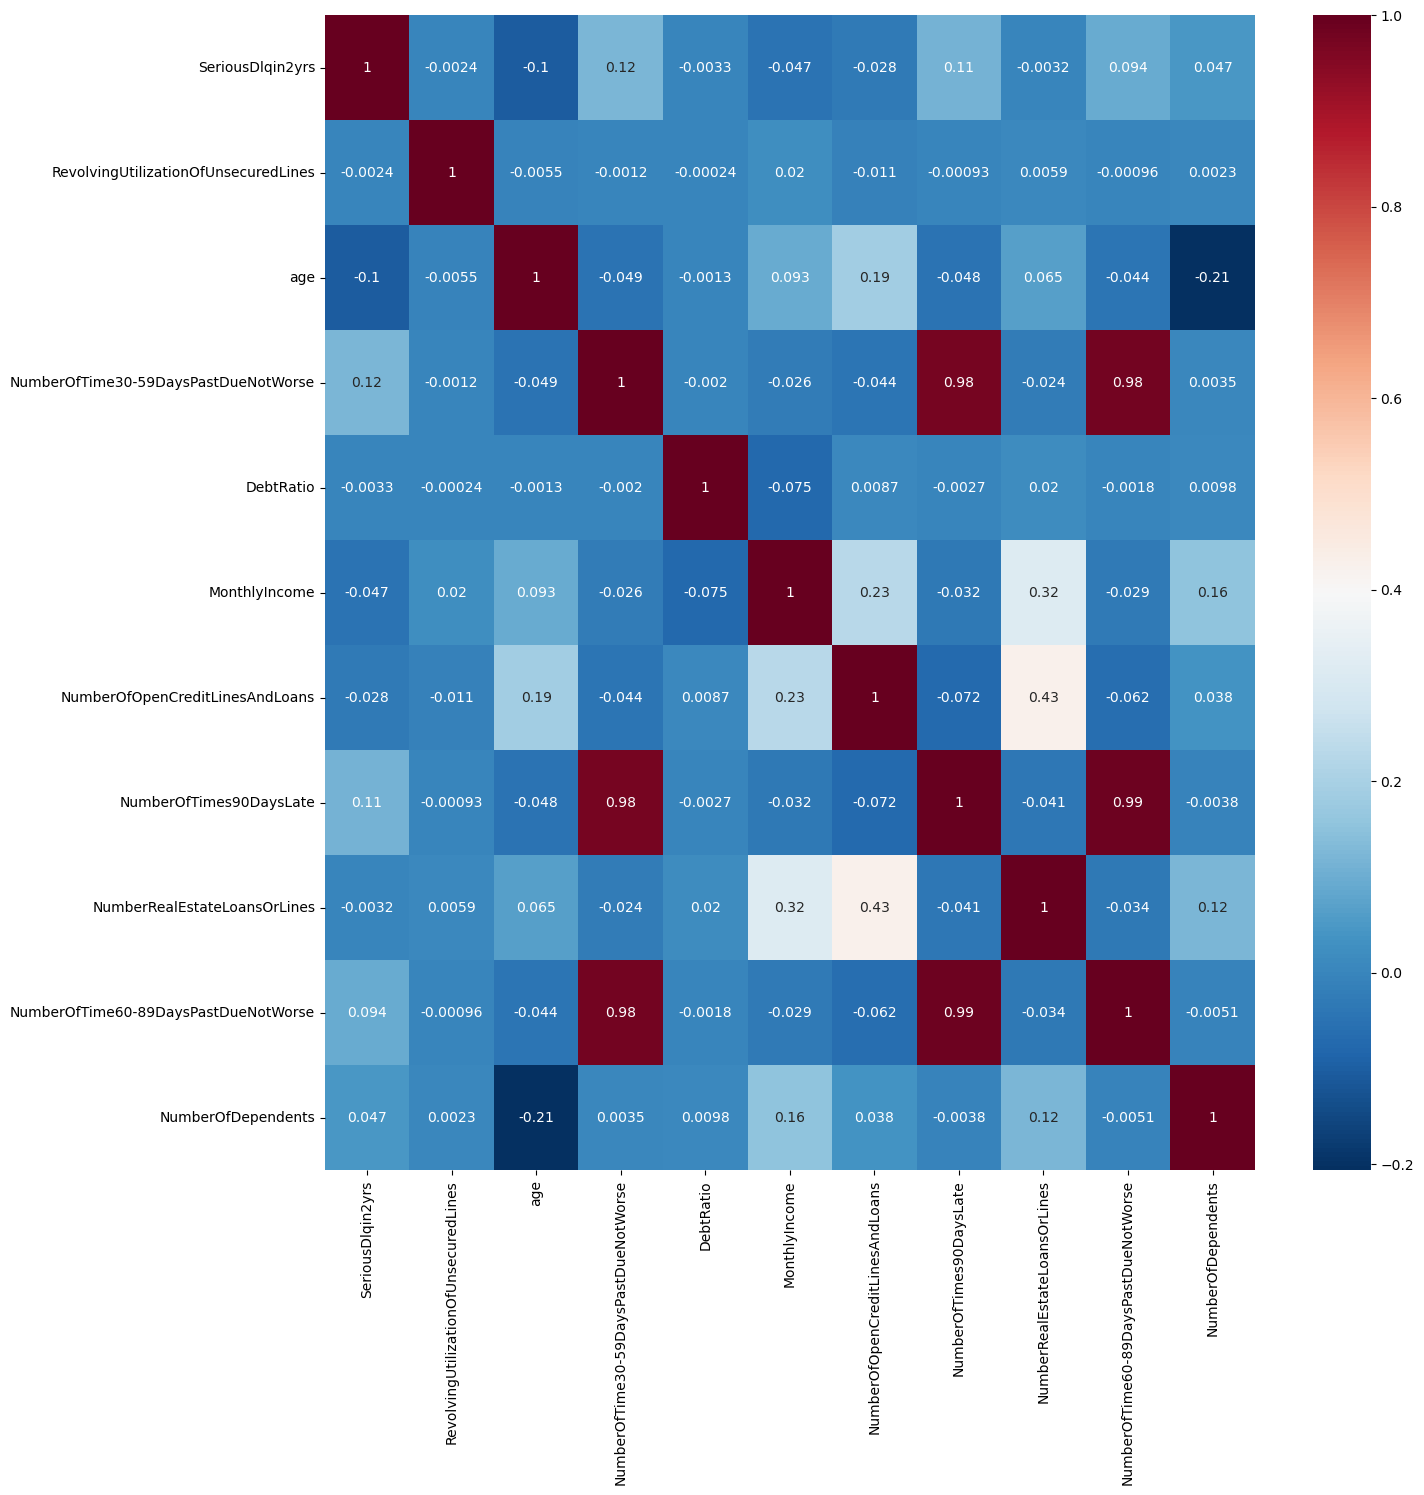

In [136]:
corr = train_df.corr();
plt.figure(figsize=(15,15))
g = sns.heatmap(corr,annot=True,cmap = "RdBu_r")
plt.show()

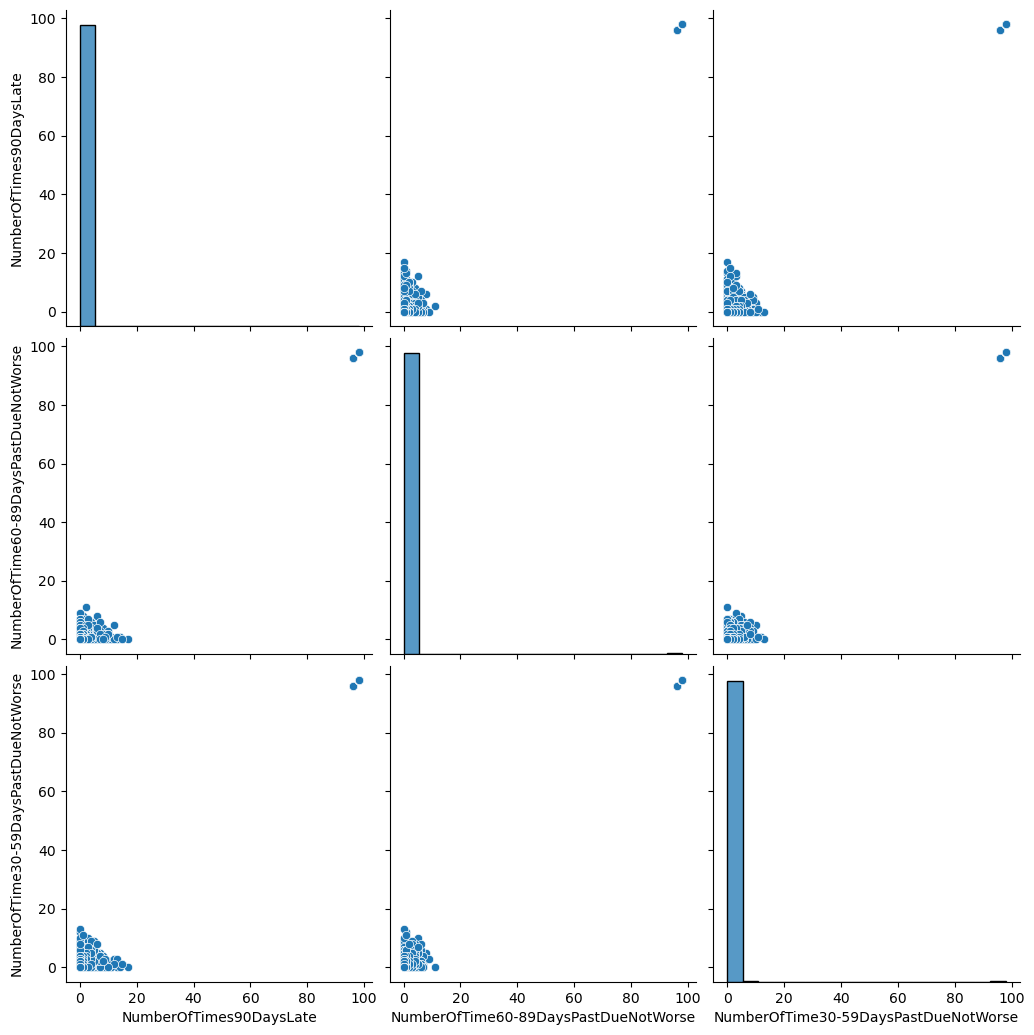

In [137]:
g = sns.pairplot(train_df[['NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTime30-59DaysPastDueNotWorse']],
                 height=3.5)
plt.show()

In [138]:
train_df[train_df['NumberOfTimes90DaysLate']>80].shape

(148, 11)

In [139]:
train_df[train_df['NumberOfTimes90DaysLate']>80].describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,148.000000,1.480000e+02,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.0,148.000000,148.000000
mean,0.567568,9.999999e-01,35.858108,97.945946,0.006556,2557.135135,0.013514,97.945946,0.0,97.945946,0.567568
std,0.497096,3.007781e-15,13.380873,0.325426,0.024678,2745.777653,0.115852,0.325426,0.0,0.325426,0.983968
min,0.000000,9.999999e-01,21.000000,96.000000,0.000000,0.000000,0.000000,96.000000,0.0,96.000000,0.000000
25%,0.000000,9.999999e-01,25.000000,98.000000,0.000000,1333.000000,0.000000,98.000000,0.0,98.000000,0.000000
50%,1.000000,9.999999e-01,31.000000,98.000000,0.000000,2168.500000,0.000000,98.000000,0.0,98.000000,0.000000
75%,1.000000,9.999999e-01,45.250000,98.000000,0.000000,3174.500000,0.000000,98.000000,0.0,98.000000,1.000000
max,1.000000,9.999999e-01,79.000000,98.000000,0.242193,28733.000000,1.000000,98.000000,0.0,98.000000,5.000000


In [140]:
train_df = train_df[~(train_df['NumberOfTimes90DaysLate']>80)]

#### После удаления выбросов корреляция уменьшилась

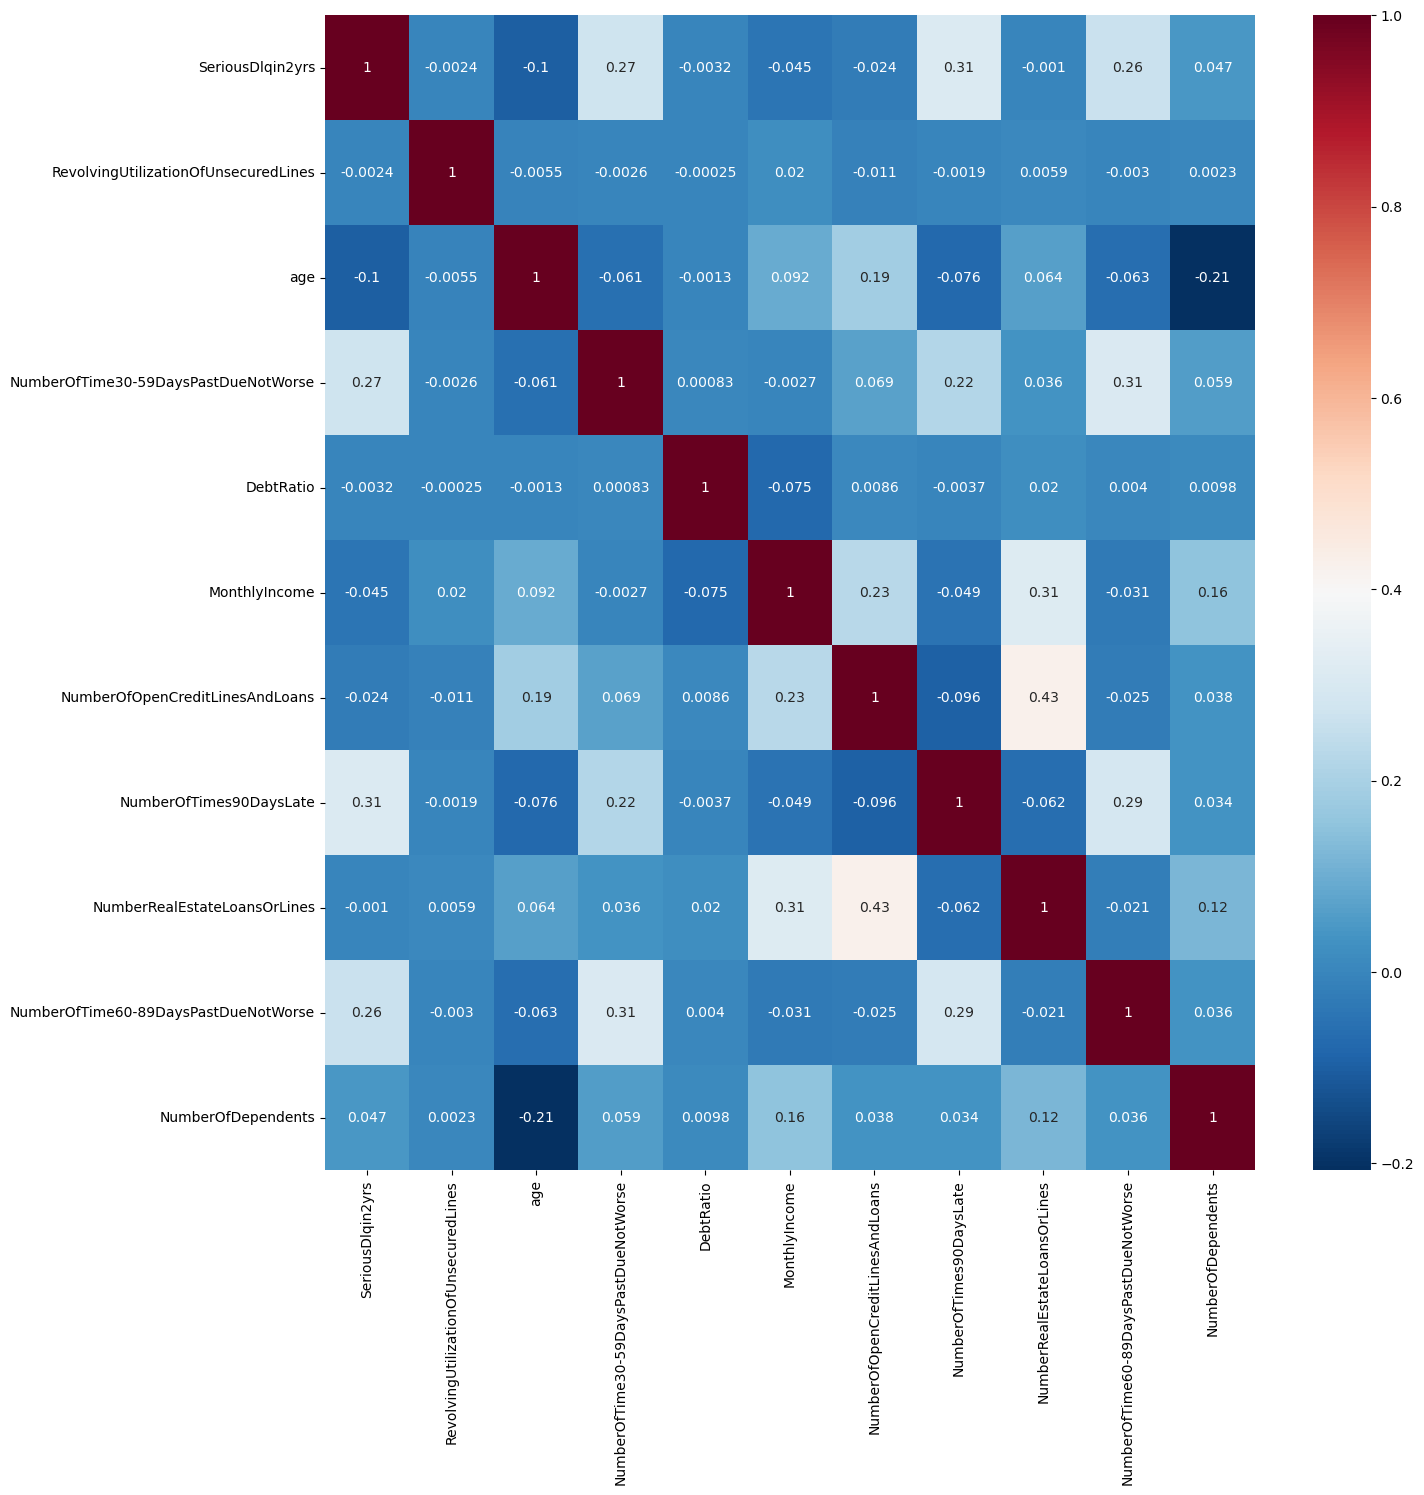

In [141]:
corr = train_df.corr();
plt.figure(figsize=(15,15))
g = sns.heatmap(corr,annot=True,cmap = "RdBu_r")
plt.show()

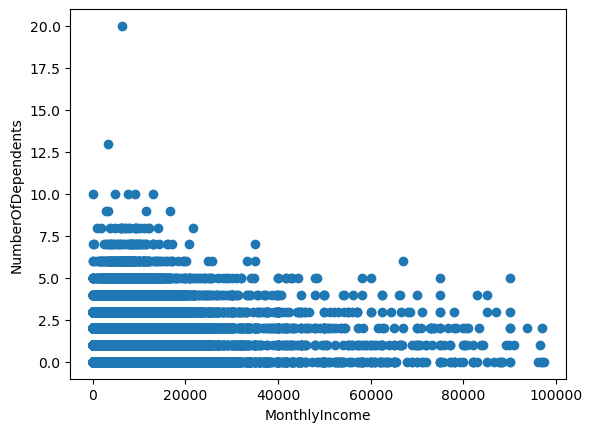

In [142]:
plt.scatter(x=train_df['MonthlyIncome'],y=train_df['NumberOfDependents'])
plt.xlabel('MonthlyIncome')
plt.ylabel('NumberOfDependents')
plt.show()

In [143]:
train_df['age'].sort_values()[:100]

65695      0
148326    21
3716      21
12989     21
122510    21
          ..
83868     21
145182    21
58993     21
17155     21
146892    21
Name: age, Length: 100, dtype: int64

In [144]:
train_df.loc[train_df['age'] == 0,:] = train_df['age'].median()

In [145]:
train_df['DebtRatio'].describe()

count    120044.000000
mean         26.649022
std         424.842485
min           0.000000
25%           0.144409
50%           0.296497
75%           0.483063
max       61106.500000
Name: DebtRatio, dtype: float64

In [146]:
quant = train_df['DebtRatio'].quantile(0.97)
quant

1.7564027453699957

In [147]:
train_df[train_df['DebtRatio'] > quant]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
14,0,0.019657,76,0,477.000000,0.0,6,0,1,0,0.0
44,0,0.368876,68,0,1687.500000,1.0,31,0,1,0,0.0
50,0,0.818978,73,0,3095.000000,0.0,9,0,1,1,0.0
73,0,0.059669,31,0,3162.000000,0.0,11,0,2,0,1.0
79,0,0.270523,41,0,2.797699,1042.0,11,0,2,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
149749,1,0.579052,47,0,8.666667,521.0,5,0,1,0,0.0
149823,0,0.820720,59,0,2.094595,2515.0,15,0,3,0,0.0
149882,0,0.062398,77,0,714.500000,1.0,3,0,0,0,0.0
149950,0,0.004827,61,0,1940.000000,0.0,10,0,1,0,0.0


In [148]:
train_df = train_df[train_df['DebtRatio'] < quant]

In [149]:
y_train = train_df['SeriousDlqin2yrs']
train_df = train_df.drop('SeriousDlqin2yrs',axis=1)

In [150]:
X_train, X_test, y_train, y_test = train_test_split(train_df,y_train,test_size=0.5)

In [151]:
sc = StandardScaler().fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [152]:
logreg = LogisticRegression(class_weight='balanced')
logreg.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [161]:
cross_val_score(logreg,X_train,y_train)

array([0.84224989, 0.83708348, 0.83553762, 0.83193061, 0.83313294])

In [162]:
y_prob = logreg.predict_proba(X_test)

In [163]:
roc_auc_score(y_test,y_prob[:,1])

0.8099496015848809

In [164]:
tree = DecisionTreeClassifier(max_depth=5)

In [165]:
tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [166]:
tree_prob = tree.predict_proba(X_test)[:,1]

In [167]:
roc_auc_score(y_test,tree_prob)

0.8266872470815697

In [168]:
rnd_forest = RandomForestClassifier(max_features=3,n_jobs=-1)

In [169]:
rnd_forest.fit(X_train,y_train)

RandomForestClassifier(max_features=3, n_jobs=-1)

In [170]:
forest_proba = rnd_forest.predict_proba(X_test)[:,1]

In [171]:
roc_auc_score(y_test,forest_proba)

0.8216768081853408

In [172]:
test_df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [173]:
test_df.drop('SeriousDlqin2yrs',axis=1,inplace=True)

In [174]:
test_df.loc[:,'MonthlyIncome'] = test_df['MonthlyIncome'].median()

In [175]:
test_df.loc[:,'NumberOfDependents'] = test_df['NumberOfDependents'].median()

In [176]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 10 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 1   age                                   101503 non-null  int64  
 2   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 3   DebtRatio                             101503 non-null  float64
 4   MonthlyIncome                         101503 non-null  float64
 5   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 6   NumberOfTimes90DaysLate               101503 non-null  int64  
 7   NumberRealEstateLoansOrLines          101503 non-null  int64  
 8   NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 9   NumberOfDependents                    101503 non-null  float64
dtypes: float64(4), int64(6)
memory usage: 7.7 MB


In [177]:
test_df = sc.transform(test_df)

In [178]:
pred = clf.predict_proba(test_df)[:,1]

In [179]:
pred = tree.predict_proba(test_df)[:,1]

In [180]:
pred = rnd_forest.predict_proba(test_df)[:,1]

In [181]:
def submission_file(predicted_labels, out_file, target='SeriousDlqin2yrs'):
    predicted_df = pd.DataFrame(predicted_labels,
                                index = np.arange(1, 
                                                  predicted_labels.shape[0] + 1),
                                columns=['Probability'])
    predicted_df.index.name = 'Id'
    predicted_df.to_csv(out_file)